In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import tensorflow.random as tf_r
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input
from scipy.optimize import curve_fit

import BuildModel as BM

plt.rcParams['font.size'] = 14

np.random.seed(12345)
tf_r.set_seed(12345)

2026-05-19 17:50:53.667083: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [6]:
np.random.seed(12345)

jump = lambda drift1, drift2, std1, std2: [int(np.random.normal(drift1,std1)), int(np.random.normal(drift2, std2))]

def pattern(i,z1,z2,a1,a2):
    return [int(a1*np.sin((np.pi*i)/z1)), int(a2*np.sin((np.pi*i)/z2))]

In [7]:
class StopAtAccuracy(tf.keras.callbacks.Callback):
    
    def __init__(self, target_acc=0.95, monitor='val_accuracy'):
        super().__init__()
        self.target_acc = target_acc
        self.monitor = monitor
        self.epochs_needed = None
        self.history = []
        self.window = 3
            
    def on_epoch_end(self, epoch, logs=None):
        self.history.append(logs.get(self.monitor, 0))
        if len(self.history) >= self.window:
            if np.mean(self.history[-self.window:]) >= self.target_acc:
                self.epochs_needed = epoch + 1
                self.model.stop_training = True

In [8]:
SNRs = [0.1, 0.5, 1, 5, 8, 10, 12, 14, 15, 16, 18, 20]
targets = [80,85,90,95]
# training set size and time series
N=10000
L=60
n_class = 3
# noise bias 
bias = 5 
MAX_EPOCHS = 350
#duration of the pattern
d = 11
# since i want to test the effectiveness of SNR as a measure classifiability 
# i start by seeing if different training sets (different amplitude and time)
# but with same SNR give more or less the same result: similar accuracy after
# a fixed number of epochs
BATCH_SIZE = 200
sigma = 20


for target in targets:
    results = []
    pattern_params = []
    # Sostituisci il loop esterno così:
    for SNR in SNRs:
        for s in np.linspace(0, 1, 5):
            A_1 = (2*(np.pi + 4)*d*SNR*s / np.pi**3)**0.5 * sigma
            A_2 = (2*(np.pi + 4)*d*SNR*(1-s) / np.pi**3)**0.5 * sigma
            pattern_params.append((A_1, sigma, bias, A_2, sigma, bias, SNR, s))  # aggiungi SNR e s alla tupla 
    
    for params in pattern_params:
        
        y = np.zeros(N) # 1D (same label)
        x = np.zeros((N,L,2))
        Z1 = Z2 = d
       
        A1, DX1, bias1, A2, DX2, bias2, SNR, s = params
        for i in range(N):
                if i>0: 
                    jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                    x[i][0][0] = x[i-1][-1][0] + jump0 
                    x[i][0][1] = x[i-1][-1][1] + jump1
                
                for j in range(1,L):
                    jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                    x[i][j][0] = x[i][j-1][0] + jump0
                    x[i][j][1] = x[i][j-1][1] + jump1
                    
                y[i] = i%3 # assign class labels (0,1,2,3,4,5,6)
                       
                if y[i]>0:
                    # 0 -> 0 0
                    if y[i]<3:
                        j01, j02 = np.random.randint(0,L-1-d, 2) 
                        sign = 3-2*y[i] 
                        
                        
                        for j in range(d): 
                           p_val1, p_val2 = pattern(j, d, d, A1, A2)
            
                           x[i][j01 + j][0] += sign * p_val1 # Canale 0
                           x[i][j02 + j][1] += sign * p_val2 # Canale 1
            
        #Show_data2D(x)
        model = BM.build_model(L, n_class=n_class)
        stop_cb = StopAtAccuracy(target_acc=target/100, monitor='val_accuracy')
        categ = y
        y = np.zeros((N,n_class))
        for i in range(N):
            y[i][int(categ[i])] = 1. # y contains one-hot encoding
    
    
        perc_train=0.8
        N_train = int(perc_train*N)
        x_train = x[:N_train]
        
        y_train = y[:N_train]
        x_val = x[N_train:]
        y_val = y[N_train:]
        N_val = len(x_val)
        
         
        #remove average value of each sample from its values
        xm_train = x_train.mean(axis=1)
        std_train = x_train.std(axis=1)
        xm_val = x_val.mean(axis=1)
        std_val = x_val.std(axis=1)
        # rescale with variance on the training set
        for i in range(N_train):
             x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
        for i in range(N_val):
            x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)
    
        x_train = x_train.reshape(x_train.shape[0], L, 2)
        x_val =  x_val.reshape(x_val.shape[0], L, 2)
        
        fit = model.fit(
            x_train, y_train,
            validation_data=(x_val, y_val),
            epochs=MAX_EPOCHS,         # upper bound di sicurezza
            callbacks=[stop_cb],
            verbose=0,shuffle=True
        )
        # Se ha raggiunto il target → epochs_needed è settato
        # Se non ha mai raggiunto il target → è None (o MAX_EPOCHS se preferisci)
        epochs_needed = stop_cb.epochs_needed or MAX_EPOCHS
        results.append({'SNR': SNR, 's': s, 'epochs': epochs_needed, 'A1': A1, 'A2': A2})
            
        print(f"Done for {params[0]}, {params[1]}, {max(fit.history['val_accuracy'])}")
    df = pd.DataFrame(results)
    fname = f'SNR{target}.csv'
    df.to_csv(fname,index=False)
    print("SAVED!!!")
    print("FINISHED!")

/home/fra/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1779205861.595586    6580 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2308 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5
2026-05-19 17:51:04.444801: I external/local_xla/xla/service/service.cc:163] XLA service 0x78c52c00cde0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-19 17:51:04.444813: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 SUPER, Compute Capability 7.5
2026-05-19 17:51:04.536140: I tensorflow/compiler/mli

Done for 0.0, 20, 0.3334999978542328


KeyboardInterrupt: 

In [ ]:
df = pd.DataFrame(results)
df.to_csv('SNR95.csv',index=False)
print("SAVED!!!")

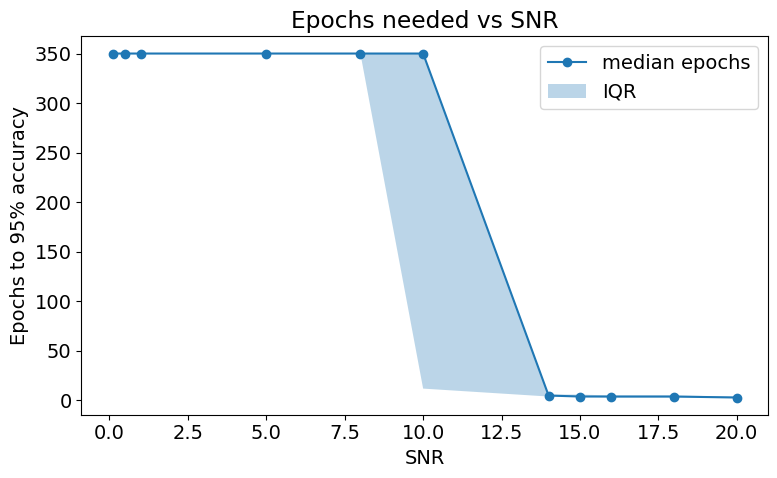

In [20]:


grouped = df.groupby('SNR')['epochs'].agg(
    median='median',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75)
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(grouped['SNR'], grouped['median'], 'o-', label='median epochs')
ax.fill_between(grouped['SNR'], grouped['p25'], grouped['p75'], alpha=0.3, label='IQR')
#ax.set_xscale('log')
ax.set_xlabel('SNR')
ax.set_ylabel('Epochs to 95% accuracy')
ax.set_title('Epochs needed vs SNR')
ax.legend()
plt.tight_layout()
plt.show()

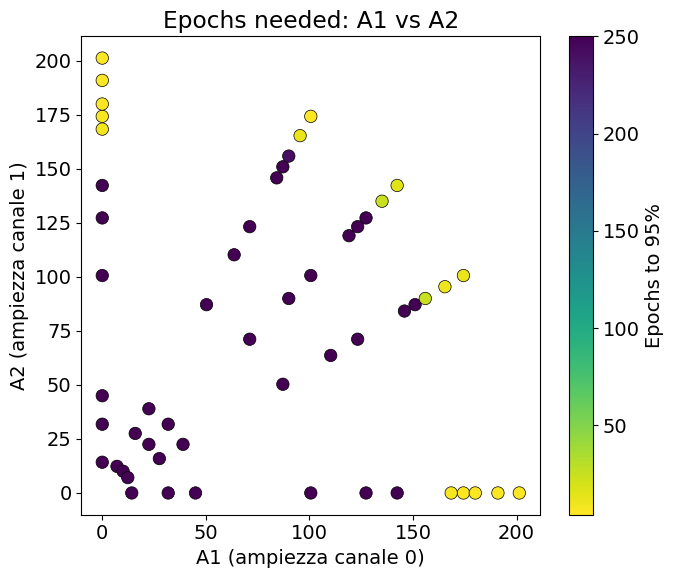

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(df['A1'], df['A2'], c=df['epochs'], 
                cmap='viridis_r', s=80, edgecolors='k', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='Epochs to 95%')
ax.set_xlabel('A1 (ampiezza canale 0)')
ax.set_ylabel('A2 (ampiezza canale 1)')
ax.set_title('Epochs needed: A1 vs A2')
plt.tight_layout()
plt.show()

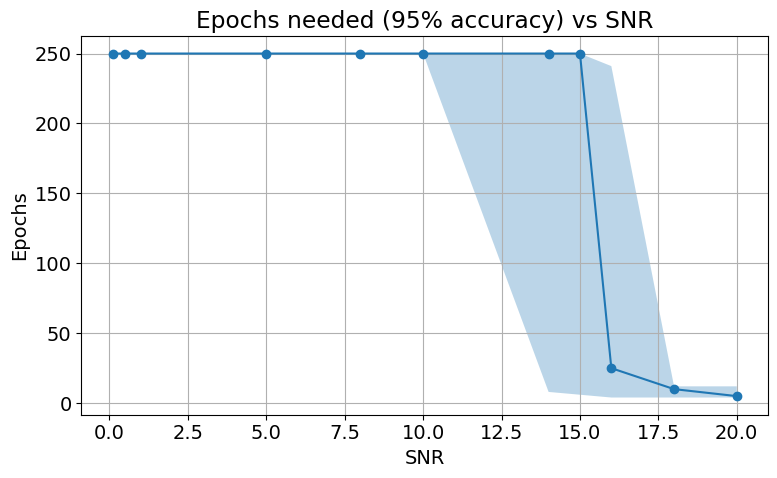

In [7]:
df = pd.read_csv("SNR.csv")
grouped = df.groupby('SNR')['epochs'].agg(
    median='median',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75)
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(grouped['SNR'], grouped['median'],'o-', label='median epochs')
ax.fill_between(grouped['SNR'], grouped['p25'], grouped['p75'], alpha=0.3, label='IQR')
#ax.set_xscale('log')
ax.set_xlabel('SNR')
ax.set_ylabel('Epochs')
ax.set_title('Epochs needed (95% accuracy) vs SNR')
ax.grid()
#ax.legend()
plt.tight_layout()
plt.show()

In [25]:
from scipy.optimize import curve_fit
from scipy.special import expit  # sigmoide
import numpy as np

datasets = [grouped95, grouped90, grouped85, grouped80]

for grouped in datasets:
    # Escludi esplicitamente i non-convergenti dal fit
    mask = grouped['median'] < MAX_EPOCHS
    
    x_fit = grouped['SNR'][mask].values
    y_fit = grouped['median'][mask].values
    
    print(f"Punti usati per il fit: {len(x_fit)}")  # controlla quanti sono
    converged = grouped[grouped['median'] < MAX_EPOCHS]
    snr_cutoff_empirico = converged['SNR'].min()
    print(f"SNR cutoff empirico: {snr_cutoff_empirico}")
    
    df['converged'] = df['epochs'] < MAX_EPOCHS
    frac = df.groupby('SNR')['converged'].mean()
    print(frac)
    
    def sigmoid_fit(snr, snr_c, k):
        return expit(k * (snr - snr_c))
    
    # Esegui il fit
    popt, pcov = curve_fit(sigmoid_fit, frac.index, frac.values, p0=[15, 0.5])
    
    # Estrai parametri e errori
    snr_cutoff = popt[0]
    k_param = popt[1]
    
    # Gli errori sono la radice quadrata della diagonale della matrice di covarianza
    perr = np.sqrt(np.diag(pcov))
    snr_cutoff_error = perr[0]
    k_error = perr[1]
    
    print(f"\nSNR cutoff dalla sigmoide: {snr_cutoff:.2f} ± {snr_cutoff_error:.2f}")
    print(f"Parametro k: {k_param:.2f} ± {k_error:.2f}")
    print(30*"-")

Punti usati per il fit: 4
SNR cutoff empirico: 15.0
SNR
0.1     0.0
0.5     0.0
1.0     0.0
5.0     0.0
8.0     0.0
10.0    0.0
12.0    0.2
14.0    0.4
15.0    0.6
16.0    0.6
18.0    1.0
20.0    1.0
Name: converged, dtype: float64

SNR cutoff dalla sigmoide: 14.62 ± 0.19
Parametro k: 0.66 ± 0.09
------------------------------
Punti usati per il fit: 5
SNR cutoff empirico: 14.0
SNR
0.1     0.0
0.5     0.0
1.0     0.0
5.0     0.0
8.0     0.0
10.0    0.0
12.0    0.2
14.0    0.4
15.0    0.6
16.0    0.6
18.0    1.0
20.0    1.0
Name: converged, dtype: float64

SNR cutoff dalla sigmoide: 14.62 ± 0.19
Parametro k: 0.66 ± 0.09
------------------------------
Punti usati per il fit: 7
SNR cutoff empirico: 10.0
SNR
0.1     0.0
0.5     0.0
1.0     0.0
5.0     0.0
8.0     0.0
10.0    0.0
12.0    0.2
14.0    0.4
15.0    0.6
16.0    0.6
18.0    1.0
20.0    1.0
Name: converged, dtype: float64

SNR cutoff dalla sigmoide: 14.62 ± 0.19
Parametro k: 0.66 ± 0.09
------------------------------
Punti usati p

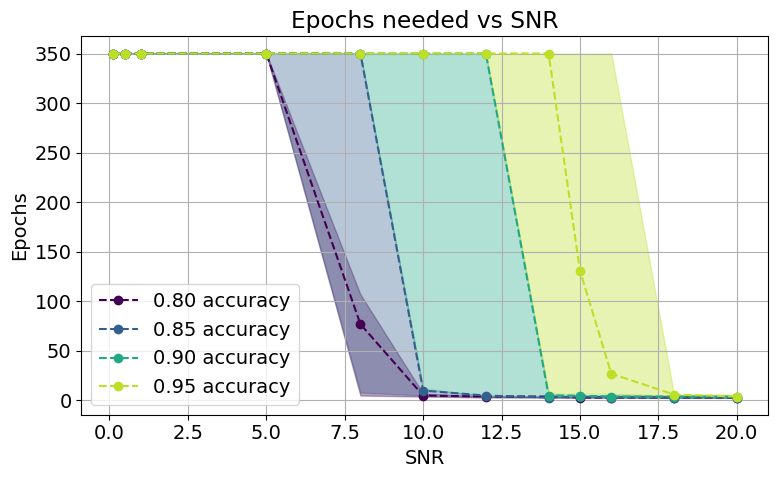

In [23]:
df80 = pd.read_csv("SNR80.csv")
df85 = pd.read_csv("SNR85.csv")
df90 = pd.read_csv("SNR90.csv")
df95 = pd.read_csv("SNR95.csv")

grouped80 = df80.groupby('SNR')['epochs'].agg(
    median='median',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75)
).reset_index()
grouped85 = df85.groupby('SNR')['epochs'].agg(
    median='median',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75)
).reset_index()
grouped90 = df90.groupby('SNR')['epochs'].agg(
    median='median',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75)
).reset_index()
grouped95 = df95.groupby('SNR')['epochs'].agg(
    median='median',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75)
).reset_index()

cmap = plt.cm.viridis
colors = [cmap(i) for i in np.linspace(0, 0.90, 4)]  # 0.85 invece di 1.0 per evitare il giallo troppo chiaro

datasets = [
    (grouped80, '0.80 accuracy'),
    (grouped85, '0.85 accuracy'),
    (grouped90, '0.90 accuracy'),
    (grouped95, '0.95 accuracy'),
]

fig, ax = plt.subplots(figsize=(8, 5))
for (grouped, label), color in zip(datasets, colors):
    ax.plot(grouped['SNR'], grouped['median'], 'o--', label=label, color=color)
    ax.fill_between(grouped['SNR'], grouped['p25'], grouped['p75'], alpha=0.35, color=color)

ax.set_xlabel('SNR')
ax.set_ylabel('Epochs')
ax.set_title('Epochs needed vs SNR')
ax.grid()
ax.legend(loc ="lower left")
plt.tight_layout()
plt.savefig("Epochs.png", dpi = 300)
plt.show()

<Figure size 640x480 with 0 Axes>

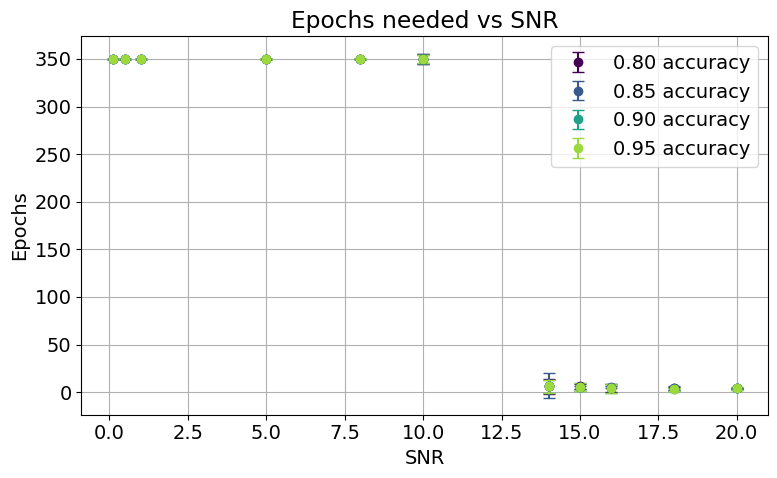

In [55]:
MAX_EPOCHS = 350

def compute_grouped(df_acc):
    results = []
    for snr, group in df_acc.groupby('SNR'):
        epochs = group['epochs']
        conv = epochs[epochs < MAX_EPOCHS]
        results.append({
            'SNR': snr,
            'median': epochs.median(),
            'std': conv.std() if len(conv) > 1 else 0,
        })
    return pd.DataFrame(results)

datasets = [
    (df80, '0.80 accuracy'),
    (df85, '0.85 accuracy'),
    (df90, '0.90 accuracy'),
    (df95, '0.95 accuracy'),
]

cmap = plt.cm.viridis
colors = [cmap(i) for i in np.linspace(0, 0.85, 4)]

fig, ax = plt.subplots(figsize=(8, 5))

for (df_acc, label), color in zip(datasets, colors):
    grouped = compute_grouped(df_acc)
    ax.errorbar(grouped['SNR'], grouped['median'],
                yerr=grouped['std'],
                fmt='o', capsize=4, label=label, color=color)

ax.set_xlabel('SNR')
ax.set_ylabel('Epochs')
ax.set_title('Epochs needed vs SNR')
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import pandas as pd

SNRs = [0.1, 0.5, 1, 5, 8, 10, 12, 14, 15, 16, 18, 20]
targets = [80, 85, 90, 95]
N = 10000
L = 60
n_class = 3
bias = 5 
MAX_EPOCHS = 350
d = 11
sigma = 20
BATCH_SIZE = 200

for target in targets:
    results = []
    
    # CORREZIONE 1: Svuota i parametri per OGNI target
    pattern_params = []
    for SNR in SNRs:
        for s in np.linspace(0, 1, 5):
            A_1 = (2 * (np.pi + 4) * d * SNR * s / np.pi**3)**0.5 * sigma
            A_2 = (2 * (np.pi + 4) * d * SNR * (1 - s) / np.pi**3)**0.5 * sigma
            pattern_params.append((A_1, sigma, bias, A_2, sigma, bias, SNR, s)) 
            
    for params in pattern_params:
        # CORREZIONE 2: Re-inizializza x e y (corretto a 1D per i calcoli) ad ogni ciclo di parametri
        x = np.zeros((N, L, 2))
        y_int = np.zeros(N, dtype=int) 
        
        A1, DX1, bias1, A2, DX2, bias2, SNR, s = params
        
        # Generazione dati temporali
        for i in range(N):
            if i > 0: 
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][0][0] = x[i-1][-1][0] + jump0 
                x[i][0][1] = x[i-1][-1][1] + jump1
            
            for j in range(1, L):
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][j][0] = x[i][j-1][0] + jump0
                x[i][j][1] = x[i][j-1][1] + jump1
                
            y_int[i] = i % 3 
            
            if y_int[i] > 0:
                if y_int[i] < 3:
                    j01, j02 = np.random.randint(0, L - 1 - d, 2) 
                    sign = 3 - 2 * y_int[i] 
                    
                    for j in range(d): 
                        p_val1, p_val2 = pattern(j, d, d, A1, A2)
                        x[i][j01 + j][0] += sign * p_val1 
                        x[i][j02 + j][1] += sign * p_val2 

        # One-hot encoding pulito senza sovrascritture distruttive
        y_onehot = np.zeros((N, n_class))
        for i in range(N):
            y_onehot[i][y_int[i]] = 1.

        # Split Train/Validation
        perc_train = 0.8
        N_train = int(perc_train * N)
        
        x_train = x[:N_train].copy()
        y_train = y_onehot[:N_train]
        x_val = x[N_train:].copy()
        y_val = y_onehot[N_train:]
        
        # CORREZIONE 3: Normalizzazione vettorizzata (più veloce e sicura)
        xm_train = x_train.mean(axis=1, keepdims=True)
        std_train = x_train.std(axis=1, keepdims=True).mean(axis=0, keepdims=True)
        
        xm_val = x_val.mean(axis=1, keepdims=True)
        std_val = x_val.std(axis=1, keepdims=True).mean(axis=0, keepdims=True)
        
        x_train = (x_train - xm_train) / std_train
        x_val = (x_val - xm_val) / std_val
        
        # Build e Fit Modello
        model = BM.build_model(L, n_class=n_class)
        stop_cb = StopAtAccuracy(target_acc=target/100, monitor='val_accuracy')
        
        fit = model.fit(
            x_train, y_train,
            validation_data=(x_val, y_val),
            epochs=MAX_EPOCHS,
            callbacks=[stop_cb],
            verbose=0, shuffle=True
        )
        
        epochs_needed = stop_cb.epochs_needed or MAX_EPOCHS
        results.append({'SNR': SNR, 's': s, 'epochs': epochs_needed, 'A1': A1, 'A2': A2})
        
        print(f"Target {target}% | Done for SNR={SNR}, s={s:.2f} | Epochs: {epochs_needed} | Max Acc: {max(fit.history['val_accuracy']):.4f}")
        
    # Salvataggio file per ogni target
    df = pd.DataFrame(results)
    fname = f'SNR{target}.csv'
    df.to_csv(fname, index=False)
    print(f"SAVED!!! {fname}")

Target 80% | Done for SNR=0.1, s=0.00 | Epochs: 350 | Max Acc: 0.3365
Target 80% | Done for SNR=0.1, s=0.25 | Epochs: 350 | Max Acc: 0.3385
Target 80% | Done for SNR=0.1, s=0.50 | Epochs: 350 | Max Acc: 0.3335
Target 80% | Done for SNR=0.1, s=0.75 | Epochs: 350 | Max Acc: 0.3365
Target 80% | Done for SNR=0.1, s=1.00 | Epochs: 350 | Max Acc: 0.3335
Target 80% | Done for SNR=0.5, s=0.00 | Epochs: 350 | Max Acc: 0.3335
Target 80% | Done for SNR=0.5, s=0.25 | Epochs: 350 | Max Acc: 0.3425
Target 80% | Done for SNR=0.5, s=0.50 | Epochs: 350 | Max Acc: 0.3365
Target 80% | Done for SNR=0.5, s=0.75 | Epochs: 350 | Max Acc: 0.3485
Target 80% | Done for SNR=0.5, s=1.00 | Epochs: 350 | Max Acc: 0.3725
Target 80% | Done for SNR=1, s=0.00 | Epochs: 350 | Max Acc: 0.4070
Target 80% | Done for SNR=1, s=0.25 | Epochs: 350 | Max Acc: 0.3915
Target 80% | Done for SNR=1, s=0.50 | Epochs: 350 | Max Acc: 0.3395
Target 80% | Done for SNR=1, s=0.75 | Epochs: 350 | Max Acc: 0.3530
Target 80% | Done for SNR=1,

/home/fra/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Target 85% | Done for SNR=0.1, s=0.00 | Epochs: 350 | Max Acc: 0.3370
Target 85% | Done for SNR=0.1, s=0.25 | Epochs: 350 | Max Acc: 0.3345
Target 85% | Done for SNR=0.1, s=0.50 | Epochs: 350 | Max Acc: 0.3335
Target 85% | Done for SNR=0.1, s=0.75 | Epochs: 350 | Max Acc: 0.3405
Target 85% | Done for SNR=0.1, s=1.00 | Epochs: 350 | Max Acc: 0.3335
Target 85% | Done for SNR=0.5, s=0.00 | Epochs: 350 | Max Acc: 0.3335
Target 85% | Done for SNR=0.5, s=0.25 | Epochs: 350 | Max Acc: 0.3570
Target 85% | Done for SNR=0.5, s=0.50 | Epochs: 350 | Max Acc: 0.3350
Target 85% | Done for SNR=0.5, s=0.75 | Epochs: 350 | Max Acc: 0.3335
Target 85% | Done for SNR=0.5, s=1.00 | Epochs: 350 | Max Acc: 0.3390
Target 85% | Done for SNR=1, s=0.00 | Epochs: 350 | Max Acc: 0.3340
Target 85% | Done for SNR=1, s=0.25 | Epochs: 350 | Max Acc: 0.4160
Target 85% | Done for SNR=1, s=0.50 | Epochs: 350 | Max Acc: 0.3370
Target 85% | Done for SNR=1, s=0.75 | Epochs: 350 | Max Acc: 0.3410
Target 85% | Done for SNR=1,

/home/fra/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Target 90% | Done for SNR=0.1, s=0.00 | Epochs: 350 | Max Acc: 0.3335
Target 90% | Done for SNR=0.1, s=0.25 | Epochs: 350 | Max Acc: 0.3360
Target 90% | Done for SNR=0.1, s=0.50 | Epochs: 350 | Max Acc: 0.3335
Target 90% | Done for SNR=0.1, s=0.75 | Epochs: 350 | Max Acc: 0.3335
Target 90% | Done for SNR=0.1, s=1.00 | Epochs: 350 | Max Acc: 0.3390
Target 90% | Done for SNR=0.5, s=0.00 | Epochs: 350 | Max Acc: 0.3380
Target 90% | Done for SNR=0.5, s=0.25 | Epochs: 350 | Max Acc: 0.3335
Target 90% | Done for SNR=0.5, s=0.50 | Epochs: 350 | Max Acc: 0.3495
Target 90% | Done for SNR=0.5, s=0.75 | Epochs: 350 | Max Acc: 0.3375
Target 90% | Done for SNR=0.5, s=1.00 | Epochs: 350 | Max Acc: 0.3335
Target 90% | Done for SNR=1, s=0.00 | Epochs: 350 | Max Acc: 0.3335
Target 90% | Done for SNR=1, s=0.25 | Epochs: 350 | Max Acc: 0.3340
Target 90% | Done for SNR=1, s=0.50 | Epochs: 350 | Max Acc: 0.3335
Target 90% | Done for SNR=1, s=0.75 | Epochs: 350 | Max Acc: 0.4135
Target 90% | Done for SNR=1,

/home/fra/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Target 95% | Done for SNR=0.1, s=0.00 | Epochs: 350 | Max Acc: 0.3375
Target 95% | Done for SNR=0.1, s=0.25 | Epochs: 350 | Max Acc: 0.3370
Target 95% | Done for SNR=0.1, s=0.50 | Epochs: 350 | Max Acc: 0.3335
Target 95% | Done for SNR=0.1, s=0.75 | Epochs: 350 | Max Acc: 0.3375
Target 95% | Done for SNR=0.1, s=1.00 | Epochs: 350 | Max Acc: 0.3390
Target 95% | Done for SNR=0.5, s=0.00 | Epochs: 350 | Max Acc: 0.3510
Target 95% | Done for SNR=0.5, s=0.25 | Epochs: 350 | Max Acc: 0.3380
Target 95% | Done for SNR=0.5, s=0.50 | Epochs: 350 | Max Acc: 0.3375
Target 95% | Done for SNR=0.5, s=0.75 | Epochs: 350 | Max Acc: 0.3620
Target 95% | Done for SNR=0.5, s=1.00 | Epochs: 350 | Max Acc: 0.3335
Target 95% | Done for SNR=1, s=0.00 | Epochs: 350 | Max Acc: 0.3460
Target 95% | Done for SNR=1, s=0.25 | Epochs: 350 | Max Acc: 0.3500
Target 95% | Done for SNR=1, s=0.50 | Epochs: 350 | Max Acc: 0.3335
Target 95% | Done for SNR=1, s=0.75 | Epochs: 350 | Max Acc: 0.3895
Target 95% | Done for SNR=1,

In [27]:
from scipy.optimize import curve_fit
from scipy.special import expit
import numpy as np

datasets = [
    (grouped95, df95, '0.95 accuracy'),
    (grouped90, df90, '0.90 accuracy'),
    (grouped85, df85, '0.85 accuracy'),
    (grouped80, df80, '0.80 accuracy'),
]

for grouped, df_original, label in datasets:
    print(f"\n{label}:")
    
    converged = grouped[grouped['median'] < MAX_EPOCHS]
    snr_cutoff_empirico = converged['SNR'].min()
    print(f"SNR cutoff empirico: {snr_cutoff_empirico}")
    
    # Calcola frac DAL dataframe originale specifico
    df_original['converged'] = df_original['epochs'] < MAX_EPOCHS
    frac = df_original.groupby('SNR')['converged'].mean()
    
    print(f"Valori di frac: {frac.values}")  # Debug: controlla se sono 0-1
    print(f"SNR values: {frac.index.values}")
    
    # Define sigmoid con clip per evitare overflow
    def sigmoid_fit(snr, snr_c, k):
        z = k * (snr - snr_c)
        z = np.clip(z, -500, 500)  # Evita overflow
        return expit(z)
    
    # Usa snr_cutoff_empirico come stima iniziale migliore per p0
    snr_c_initial = snr_cutoff_empirico if not np.isnan(snr_cutoff_empirico) else 15
    k_initial = 0.5  # k piccolo per iniziare
    
    try:
        popt, pcov = curve_fit(
            sigmoid_fit, 
            frac.index.values, 
            frac.values, 
            p0=[snr_c_initial, k_initial],
            bounds=([0, -5], [50, 5]),  # Vincoli ragionevoli
            maxfev=5000  # Aumenta il numero massimo di valutazioni
        )
        perr = np.sqrt(np.diag(pcov))
        
        snr_cutoff = popt[0]
        snr_cutoff_error = perr[0]
        
        print(f"SNR cutoff dalla sigmoide: {snr_cutoff:.2f} ± {snr_cutoff_error:.2f}")
        print(f"Parametro k: {popt[1]:.2f} ± {perr[1]:.2f}")
        
    except RuntimeError as e:
        print(f"Fit fallito: {e}")
        print(f"Usando cutoff empirico invece: {snr_cutoff_empirico}")


0.95 accuracy:
SNR cutoff empirico: 15.0
Valori di frac: [0.  0.  0.  0.  0.  0.  0.2 0.4 0.6 0.6 1.  1. ]
SNR values: [ 0.1  0.5  1.   5.   8.  10.  12.  14.  15.  16.  18.  20. ]
SNR cutoff dalla sigmoide: 14.62 ± 0.19
Parametro k: 0.66 ± 0.09

0.90 accuracy:
SNR cutoff empirico: 14.0
Valori di frac: [0.  0.  0.  0.  0.  0.4 0.4 1.  1.  1.  1.  1. ]
SNR values: [ 0.1  0.5  1.   5.   8.  10.  12.  14.  15.  16.  18.  20. ]
SNR cutoff dalla sigmoide: 11.53 ± 0.37
Parametro k: 0.77 ± 0.18

0.85 accuracy:
SNR cutoff empirico: 10.0
Valori di frac: [0.  0.  0.  0.  0.4 0.8 1.  1.  1.  1.  1.  1. ]
SNR values: [ 0.1  0.5  1.   5.   8.  10.  12.  14.  15.  16.  18.  20. ]
SNR cutoff dalla sigmoide: 8.47 ± 0.06
Parametro k: 0.99 ± 0.05

0.80 accuracy:
SNR cutoff empirico: 8.0
Valori di frac: [0.  0.  0.  0.  0.8 1.  1.  1.  1.  1.  1.  1. ]
SNR values: [ 0.1  0.5  1.   5.   8.  10.  12.  14.  15.  16.  18.  20. ]
SNR cutoff dalla sigmoide: 7.72 ± 0.01
Parametro k: 4.90 ± 0.16
